Implement a Denoising Autoencoder for removing noise from images.

    Load the MNIST dataset.
    Add random Gaussian noise to the training and testing images.
    Construct an Autoencoder with an appropriate encoder and decoder.
    Train the model using:
    Noisy images as input
    Original clean images as target
    Display three sets of images:
    Original image
    Noisy image
    Reconstructed/denoised image
    Compare the reconstruction quality.

Expected output should be :
The trained Autoencoder should remove a significant amount of noise while preserving the digit structure.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 151ms/step - loss: 0.1650 - val_loss: 0.1161
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 147ms/step - loss: 0.1123 - val_loss: 0.1079
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 146ms/step - loss: 0.1068 - val_loss: 0.1044
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 146ms/step - loss: 0.1041 - val_loss: 0.1021
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 146ms/step - loss: 0.1024 - val_loss: 0.1009
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 150ms/step - loss: 0.1009 - val_loss: 0.0994
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 149ms/step - loss: 0.0998 - val_loss: 0.0984
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - loss: 0.0990 - val_loss: 0.0978
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 146ms/step - loss: 0.0984 - val_loss: 0.0971
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - loss: 0.0978 - val_loss: 0.0968
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


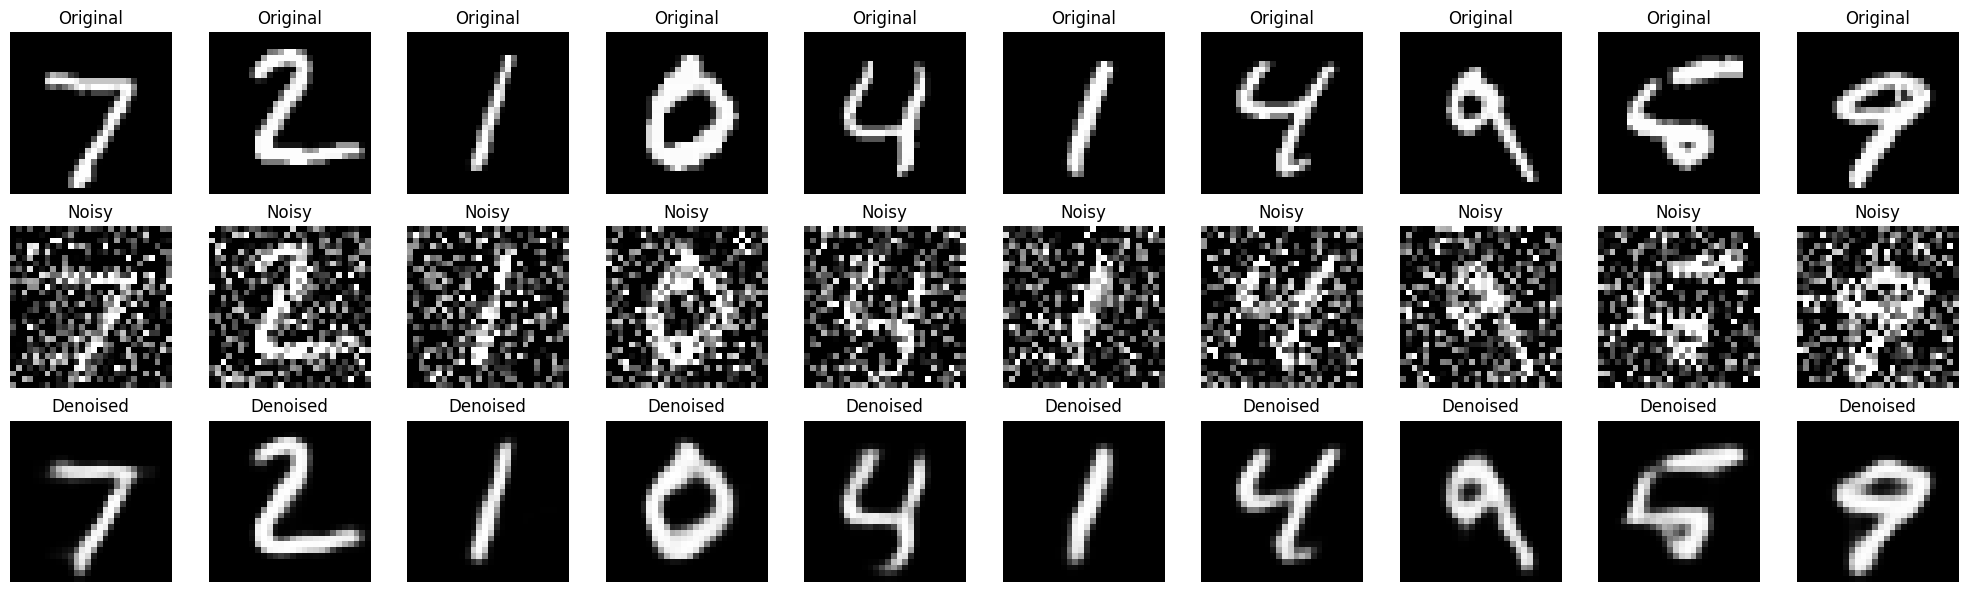

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

# -----------------------------
# 1. Load the MNIST Dataset
# -----------------------------
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize images
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Reshape for CNN
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# -----------------------------
# 2. Add Gaussian Noise
# -----------------------------
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# -----------------------------
# 3. Build Denoising Autoencoder
# -----------------------------
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam',
                    loss='binary_crossentropy')

autoencoder.summary()

# -----------------------------
# 4. Train the Autoencoder
# -----------------------------
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

# -----------------------------
# 5. Reconstruct Images
# -----------------------------
decoded_imgs = autoencoder.predict(x_test_noisy)

# -----------------------------
# 6. Display Results
# -----------------------------
n = 10
plt.figure(figsize=(20,6))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()